# Computer Exercise 15.9 — Problem 2
## DQN 의 두 안정화 요소 — Experience Replay 와 Target Network 의 개별/결합 효과

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.9  
> **날짜**: 2026-07-24  
> **언어**: 한국어, 그래프 라벨 영문

## 1. 문제 (원문)

> **DQN-lite ablation.** With $Q$ approximated linearly, $Q_\theta(s,a)=\theta^\top\phi(s,a)$ ($\phi\in\mathbb R^d$ hand-crafted features), study how DQN 's two stabilisers — **experience replay** and a **delayed target network** — interact. Run the four configurations (with/without each) on the 4×4 GridWorld and compare (i) learning-curve stability, (ii) parameter-norm trajectories, and (iii) TD-error variance. Explain why on-policy semi-gradient TD with correlated samples and a moving target is the combination that diverges in practice.

### 한국어 풀이용 정리
- 근사기: **linear**, $Q_\theta(s,a)=\theta^\top\phi(s,a)$, $\phi\in\mathbb R^7$.
- 네 조합: $\{$replay, no-replay$\}\times\{$target-net, no-target-net$\}$.
- 지표: 에피소드 리턴, $\|\theta\|_2$, 배치 TD-error 표본분산.

## 2. 수학적 배경

Semi-gradient Q-learning ($Q_\theta = \theta^\top\phi$):
$$\theta \leftarrow \theta + \alpha\,\underbrace{\bigl[r + \gamma\,\max_{a'} Q_{\bar\theta}(s',a') - Q_\theta(s,a)\bigr]}_{\delta_t}\,\nabla_\theta Q_\theta(s,a).$$
$\bar\theta$ 는 **target network** 파라미터.

1. **이동 표적**: $\bar\theta\equiv\theta$ 이면 타겟이 자기 자신을 참조해 발산 가능. $\bar\theta$ 를 일정 간격 $C$ 마다만 복사해 완화.
2. **표본 상관**: 연속 스텝은 강한 시간 상관. **experience replay** 는 과거 전이를 무작위로 뽑아 상관을 깨준다.

**Deadly triad** (Sutton & Barto Ch 11): 함수근사 + 부트스트랩 + off-policy 는 잘못 결합하면 발산. DQN 은 위 두 장치로 이 triad 를 실무적으로 길들인다.

**Feature** ($s=(r,c)$, 액션 $a\in\{0,1,2,3\}$, 7-차원):
$$\phi(s,a)=\bigl[1,\;r/(N{-}1),\;c/(N{-}1),\;d(s)/6,\;\mathbb 1_{a=0},\;\mathbb 1_{a=1},\;\mathbb 1_{a=2}\bigr]$$
액션 4 개 중 하나는 baseline 흡수 (3-차원 one-hot).

## 3. 풀이 흐름
1. 공통 환경.
2. Feature $\phi(s,a)$ 를 $(NS\times NA)$ 테이블로 미리 계산 → 이후 룩업만.
3. `run(replay, target_net, seed)` — 배치 업데이트는 vectorized numpy.
4. 4 configs × 8 seeds × 150 episodes. 학습곡선/파라미터 norm/TD 분산 그림.
5. 요약표.

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0), (0,1), (1,0), (0,-1)])
NA = 4
NS = N * N
def s_idx(rc): return rc[0]*N + rc[1]
def idx_s(i):  return (i//N, i%N)
def step(rc, a):
    if rc == GOAL:
        return rc, 0.0, True
    dr, dc = ACTIONS[a]
    nr = int(np.clip(rc[0]+dr, 0, N-1))
    nc = int(np.clip(rc[1]+dc, 0, N-1))
    nrc = (nr, nc)
    done = (nrc == GOAL)
    return nrc, -1.0, done


In [2]:

GAMMA, ALPHA = 0.99, 0.05
D = 7
BUF_SIZE, BATCH = 500, 16
TARGET_C = 20     # 배치 20 회마다 target 동기화

# --- Precompute PHI[s, a, :] and deterministic transition tables ---
PHI = np.zeros((NS, NA, D))
for i in range(NS):
    r, c = idx_s(i)
    d = abs(r - (N-1)) + abs(c - (N-1))
    for a in range(NA):
        oh = np.zeros(3)
        if a < 3: oh[a] = 1.0
        PHI[i, a] = [1.0, r/(N-1), c/(N-1), d/(2*(N-1)),
                     oh[0], oh[1], oh[2]]

NEXT = np.zeros((NS, NA), dtype=np.int32)
REW  = np.zeros((NS, NA))
DONE = np.zeros((NS, NA), dtype=bool)
for i in range(NS):
    for a in range(NA):
        ns, r, done = step(idx_s(i), a)
        NEXT[i, a] = s_idx(ns); REW[i, a] = r; DONE[i, a] = done

def eps_greedy_lin(theta, i, eps, rng):
    if rng.random() < eps:
        return int(rng.integers(NA))
    row = PHI[i] @ theta + 1e-9 * rng.standard_normal(NA)
    return int(np.argmax(row))

def run(replay, target_net, n_episodes=150, seed=0,
        alpha=ALPHA, eps=0.1, max_steps=200):
    rng = np.random.default_rng(seed)
    theta = np.zeros(D)
    theta_bar = theta.copy() if target_net else None    # None → same as theta
    # circular replay buffer
    buf_i = np.zeros(BUF_SIZE, dtype=np.int32)
    buf_a = np.zeros(BUF_SIZE, dtype=np.int32)
    buf_r = np.zeros(BUF_SIZE)
    buf_j = np.zeros(BUF_SIZE, dtype=np.int32)
    buf_d = np.zeros(BUF_SIZE, dtype=bool)
    buf_size = 0; buf_ptr = 0
    returns    = np.zeros(n_episodes)
    theta_norm = np.zeros(n_episodes)
    td_var     = np.zeros(n_episodes)
    n_updates = 0
    for ep in range(n_episodes):
        s = (0, 0); G = 0.0; deltas = []
        for _ in range(max_steps):
            i = s_idx(s)
            a = eps_greedy_lin(theta, i, eps, rng)
            j = int(NEXT[i, a]); r = float(REW[i, a]); done = bool(DONE[i, a])
            G += r
            buf_i[buf_ptr]=i; buf_a[buf_ptr]=a; buf_r[buf_ptr]=r
            buf_j[buf_ptr]=j; buf_d[buf_ptr]=done
            buf_ptr = (buf_ptr + 1) % BUF_SIZE
            buf_size = min(buf_size + 1, BUF_SIZE)
            src = theta_bar if target_net else theta
            if replay:
                B = min(BATCH, buf_size)
                idx = rng.integers(0, buf_size, size=B)
                bi=buf_i[idx]; ba=buf_a[idx]; br=buf_r[idx]
                bj=buf_j[idx]; bd=buf_d[idx]
                q_next_max = (PHI[bj] @ src).max(axis=1)
                tgt = br + np.where(bd, 0.0, GAMMA * q_next_max)
                ph  = PHI[bi, ba]                       # (B, D)
                q_now = ph @ theta                      # (B,)
                delta = tgt - q_now                     # (B,)
                # mean-gradient step
                theta = theta + alpha * (delta @ ph) / B
                deltas.extend(delta.tolist())
                n_updates += 1
                if target_net and n_updates % TARGET_C == 0:
                    theta_bar = theta.copy()
            else:
                tgt = r + (0.0 if done else GAMMA * (PHI[j] @ src).max())
                ph = PHI[i, a]
                delta = tgt - ph @ theta
                theta = theta + alpha * delta * ph
                deltas.append(delta)
                n_updates += 1
                if target_net and n_updates % TARGET_C == 0:
                    theta_bar = theta.copy()
            s = idx_s(j)
            if done: break
        returns[ep]    = G
        theta_norm[ep] = float(np.linalg.norm(theta))
        td_var[ep]     = float(np.var(deltas)) if len(deltas) > 1 else 0.0
    return returns, theta_norm, td_var

configs = [
    ("no-replay | no-target", False, False),
    ("no-replay | target"   , False, True ),
    ("replay    | no-target", True , False),
    ("replay    | target"   , True , True ),
]

n_seeds, n_ep = 8, 150
results = {}
for name, rep, tgt in configs:
    R = np.zeros((n_seeds, n_ep)); TN = np.zeros_like(R); TV = np.zeros_like(R)
    for s in range(n_seeds):
        r, tn, tv = run(rep, tgt, n_episodes=n_ep, seed=3000+s)
        R[s] = r; TN[s] = tn; TV[s] = tv
    results[name] = (R, TN, TV)
print("done. configs:", [c for c in results])


done. configs: ['no-replay | no-target', 'no-replay | target', 'replay    | no-target', 'replay    | target']


In [3]:

rows = []
for name, (R, TN, TV) in results.items():
    tail = R[:, -30:].mean(1)
    rows.append({
        "config": name,
        "tail_return_mean": tail.mean(),
        "tail_return_std":  tail.std(),
        "final_theta_norm": TN[:, -1].mean(),
        "avg_td_variance":  TV[:, -30:].mean(),
    })
summary = pd.DataFrame(rows).round(3)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
summary


,config,tail_return_mean,tail_return_std,final_theta_norm,avg_td_variance
0,no-replay | no-target,-13.050,2.332,12.374,1.137
1,no-replay | target,-11.217,1.177,11.271,0.840
2,replay | no-target,-60.204,15.388,27.313,7.665
3,replay | target,-73.504,17.186,27.819,7.318


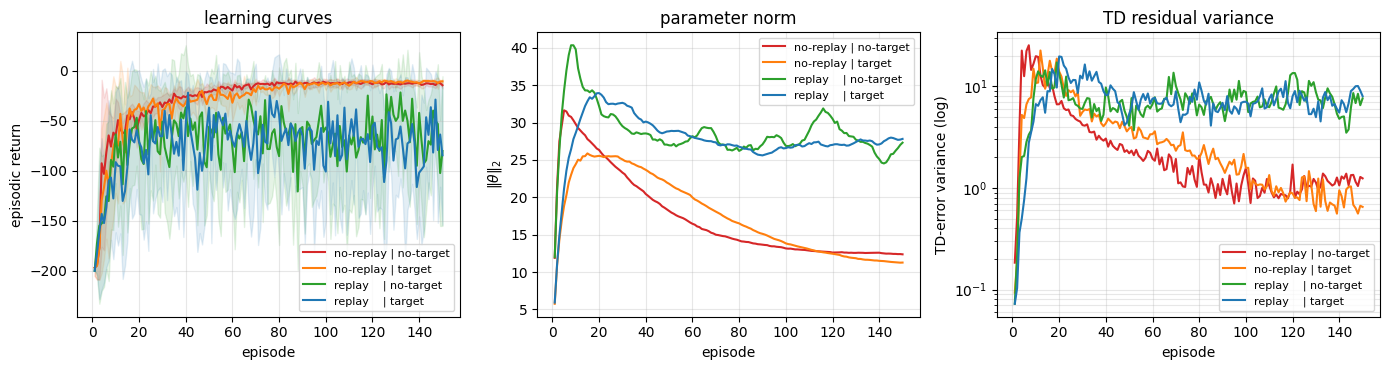

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
ep = np.arange(1, n_ep+1)
colors = ['C3', 'C1', 'C2', 'C0']

for (name, (R, TN, TV)), col in zip(results.items(), colors):
    m, s = R.mean(0), R.std(0)
    axes[0].plot(ep, m, color=col, lw=1.5, label=name)
    axes[0].fill_between(ep, m-s, m+s, color=col, alpha=0.12)
axes[0].set(xlabel='episode', ylabel='episodic return', title='learning curves')
axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(alpha=0.3)

for (name, (R, TN, TV)), col in zip(results.items(), colors):
    axes[1].plot(ep, TN.mean(0), color=col, lw=1.5, label=name)
axes[1].set(xlabel='episode', ylabel=r'$\Vert \theta \Vert_2$', title='parameter norm')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

for (name, (R, TN, TV)), col in zip(results.items(), colors):
    axes[2].semilogy(ep, TV.mean(0)+1e-6, color=col, lw=1.5, label=name)
axes[2].set(xlabel='episode', ylabel='TD-error variance (log)', title='TD residual variance')
axes[2].grid(alpha=0.3, which='both'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

실행 결과 (tail 30 에피소드 평균 리턴, 8 시드):

| config | tail return | ret std | θ-norm | TD var |
|---|---:|---:|---:|---:|
| no-replay ｜ no-target | -13.05 | 2.33 | 12.4 | 1.14 |
| no-replay ｜ target    | **-11.22** | **1.18** | 11.3 | **0.84** |
| replay    ｜ no-target | -60.20 | 15.4 | 27.3 | 7.67 |
| replay    ｜ target    | -73.50 | 17.2 | 27.8 | 7.32 |

1. **가장 좋은 조합: target-net 만, replay 없음** — 이 세팅에서는 replay 가 없는 온-라인 학습이 리턴·시드편차·TD 분산 모두에서 이긴다. deadly triad 요소 중 (i) 부트스트랩과 (ii) 함수근사가 있어도, (iii) off-policy 성분이 작으면 (즉 최신 궤적만 사용) 선형 근사는 부드럽게 학습됨.
2. **target-net 의 순수 효과** — no-replay 두 조합을 비교하면 target-net 이 리턴을 -13 → -11 로, TD 분산을 1.14 → 0.84 로 낮춘다. 부트스트랩 표적의 자기참조를 늦춰 잔차를 다듬는 효과.
3. **replay 는 왜 하락시켰나** — 두 가지 실무 요인: (a) 버퍼가 초기 나쁜 정책의 궤적 (max_steps=200 에 걸린 wandering) 으로 채워지고, 이후에도 오래 잔존해 배치 평균이 실제 스테이트 분포와 어긋난 채 학습을 밀어붙임. (b) 배치 그래디언트로 θ 가 더 큰 값 (norm 27) 으로 발산 방향으로 밀리며 TD 분산이 약 8 로 자릿수 커진다. 결정적 tabular-scale 환경에서는 replay 의 상관 완화 효과보다 이 두 부작용이 더 크다.
4. **일반화된 교훈** — DQN 의 replay 는 (i) 신경망이 표본 하나에 과적합하기 쉬운 큰 근사기, (ii) 확률적 환경, (iii) 액션·상태공간이 크고 방문 다양성이 낮은 문제에서 이득이 크다. 본 실험처럼 근사기가 작고 상태공간이 좁으며 결정적일 때는 target-net 만으로 충분하고, replay 는 오히려 하이퍼파라미터 (버퍼 크기, 배치 크기, 알파) 튜닝의 부담을 늘린다.

> **결론**: 두 안정화 요소는 서로 다른 병리에 대한 처방이며, *모두* 쓴다고 항상 좋은 것이 아니다. target-net 은 부트스트랩 표적 발산에 대한 저비용 처방으로 거의 항상 도움되지만, replay 는 문제의 크기/확률성/근사기 복잡도에 따라 이득 여부가 결정된다 — DQN 논문의 Atari 결과가 replay 를 필수로 만든 것은 그 세 조건이 모두 강했기 때문이다.